In [1]:
# Ô lệnh do kaggle_run.sh chèn vào — đặt chế độ chạy trước khi notebook đọc biến này.
import os
os.environ['SMOKE_TEST'] = '0'
print('SMOKE_TEST =', os.environ['SMOKE_TEST'], '->', 'thử nhanh' if os.environ['SMOKE_TEST'] == '1' else 'chạy đầy đủ')

SMOKE_TEST = 0 -> chạy đầy đủ


# Lazada Uplift — 10 · Chọn ngưỡng quyết định

Mô hình cho ra `uplift_score` liên tục. Chiến dịch thì cần một quyết định nhị phân: **phát voucher
hay không**. Notebook này trả lời câu hỏi cắt ở đâu.

Ngưỡng đang dùng trước đó là `0.02`, đặt bằng tay, không dựa trên gì cả. Đây là chỗ hổng thật, vì
điểm của DR-Learner **không được hiệu chuẩn**: thang tuyệt đối của nó không khớp với thang uplift
thật, nên một con số như "2 điểm phần trăm" không có nghĩa gì trong thang đó.

Cách sửa: **đường cong Qini biết ngưỡng nằm ở đâu**, chỉ là phải hỏi nó đúng cách.

> ### Notebook này đọc gì và không đọc gì
>
> Chỉ **đọc** artifact đã có: `04a_cate_select.npz`, `decisions_locked.json`, `rct_select.parquet`.
> Không huấn luyện lại mô hình nào, không sửa notebook nào khác, và **không mở `rct_holdout`** —
> chọn ngưỡng là một quyết định, mà mọi quyết định đều phải ra trên `rct_select`.
>
> Đầu ra: `artifacts/nguong_quyet_dinh.json` và năm hình trong `reports/figures/`.

---
# Phần 1 — Thiết lập

### Bước 1 — Thư viện, đường dẫn và bảng màu

Bảng màu đặt tên theo *vai trò* chứ không theo màu, để mọi hình trong notebook dùng chung một hệ và
đổi màu chỉ phải sửa một chỗ. Ba màu chuỗi dữ liệu đã qua kiểm tra tương phản và kiểm tra mù màu
(deutan/protan/tritan), nên hai đường bất kỳ trên cùng một hình luôn phân biệt được.

In [2]:
import os
if os.path.exists('/kaggle'):
    get_ipython().run_line_magic('pip', 'install -q econml')
else:
    print('Local: dependencies are managed by uv (uv sync --frozen).')

Local: dependencies are managed by uv (uv sync --frozen).


In [3]:
import os
import glob
import json
import hashlib
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from matplotlib.ticker import PercentFormatter, FuncFormatter

warnings.filterwarnings('ignore')

IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    print('📌 Đang chạy trên Kaggle Environment')
    _ung_vien = [os.path.dirname(f) for f in
                 glob.glob('/kaggle/input/**/rct_select.parquet', recursive=True)]
    if not _ung_vien:
        raise FileNotFoundError('Không tìm thấy rct_select.parquet trong /kaggle/input.')
    DATA_DIR = _ung_vien[0]
    ART_DIR = '/kaggle/working/artifacts'
    FIG_DIR = '/kaggle/working/reports/figures'
else:
    print('📌 Đang chạy trên máy Local')
    ROOT = '..' if os.path.basename(os.getcwd()) == 'notebooks' else '.'
    DATA_DIR = os.path.join(ROOT, 'dataset')
    ART_DIR = os.path.join(ROOT, 'artifacts')
    FIG_DIR = os.path.join(ROOT, 'reports', 'figures')

os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

TRAPZ = getattr(np, 'trapezoid', None) or np.trapz

print(f'DATA_DIR: {DATA_DIR}')
print(f'ART_DIR : {ART_DIR}')
print(f'FIG_DIR : {FIG_DIR}')

📌 Đang chạy trên máy Local
DATA_DIR: ../dataset
ART_DIR : ../artifacts
FIG_DIR : ../reports/figures


In [4]:
# --- Bảng màu: đặt tên theo vai trò, không theo màu ---
MAU = {
    'nen':        '#fcfcfb',   # nền hình
    'muc_chinh':  '#0b0b0b',   # chữ tiêu đề
    'muc_phu':    '#52514e',   # chữ nhãn
    'muc_mo':     '#898781',   # trục, tick
    'luoi':       '#e1e0d9',   # đường lưới
    'truc':       '#c3c2b7',   # đường trục, mốc nền
    'chuoi_1':    '#2a78d6',   # xanh dương — mô hình / nhóm được phát
    'chuoi_2':    '#eb6834',   # cam — ngưỡng được chọn / phương án mới
    'chuoi_3':    '#1baf7a',   # xanh ngọc — dùng kèm nhãn trực tiếp
    'tot':        '#0ca30c',
    'canh_bao':   '#d03b3b',
}

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 160,
    'figure.facecolor': MAU['nen'],
    'axes.facecolor': MAU['nen'],
    'savefig.facecolor': MAU['nen'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.titlecolor': MAU['muc_chinh'],
    'axes.titlelocation': 'left',
    'axes.labelcolor': MAU['muc_phu'],
    'text.color': MAU['muc_phu'],
    'xtick.color': MAU['muc_mo'],
    'ytick.color': MAU['muc_mo'],
    'xtick.labelcolor': MAU['muc_phu'],
    'ytick.labelcolor': MAU['muc_phu'],
    'legend.frameon': False,
    'lines.linewidth': 2,
    'lines.markersize': 8,
})


def khung(ax, luoi='y'):
    '''Bỏ viền thừa, để lưới lùi về sau — dữ liệu là thứ nổi lên trước.'''
    for canh in ('top', 'right'):
        ax.spines[canh].set_visible(False)
    for canh in ('left', 'bottom'):
        ax.spines[canh].set_color(MAU['truc'])
        ax.spines[canh].set_linewidth(1)
    ax.set_axisbelow(True)
    if luoi:
        ax.grid(axis=luoi, color=MAU['luoi'], linewidth=0.9)
        ax.grid(axis={'y': 'x', 'x': 'y'}.get(luoi, 'x'), visible=False)
    ax.tick_params(length=0)
    return ax


NGHIN = FuncFormatter(lambda v, _: f'{v:,.0f}')


def dat_tieu_de(ax, chinh, phu=None):
    '''Tiêu đề trên, dòng chú thích nhỏ ngay dưới — chừa sẵn chỗ để không đè nhau.'''
    ax.set_title(chinh, pad=30 if phu else 10)
    if phu:
        ax.text(0, 1.035, phu, transform=ax.transAxes, va='bottom',
                color=MAU['muc_mo'], fontsize=9)


def dat_tieu_de_fig(fig, chinh, phu=None, x=0.008):
    '''Bản cho hình nhiều khung — nhớ tight_layout(rect=(0, 0, 1, 0.87)).'''
    fig.suptitle(chinh, x=x, ha='left', y=0.995, va='top',
                 fontsize=12.5, fontweight='bold', color=MAU['muc_chinh'])
    if phu:
        fig.text(x, 0.935, phu, color=MAU['muc_mo'], fontsize=9, va='top')


print('Đã nạp bảng màu, khung() và hai hàm đặt tiêu đề')

Đã nạp bảng màu, khung() và hai hàm đặt tiêu đề


### Bước 2 — Chế độ chạy

Notebook không huấn luyện gì. `N_BOOT` là thứ duy nhất tốn thời gian: mỗi lần lấy mẫu lại phải dựng
lại toàn bộ đường cong Qini trên 90 nghìn dòng.

In [5]:
SMOKE_TEST = os.environ.get('SMOKE_TEST', '1').lower() not in ('0', 'false', 'no')

N_BOOT = 60 if SMOKE_TEST else 400
RUN_MODE = 'smoke_test' if SMOKE_TEST else 'full'

print('=' * 68)
print(f'  10 — CHỌN NGƯỠNG QUYẾT ĐỊNH   |   CHẾ ĐỘ: {RUN_MODE.upper()}')
print(f'  Bootstrap: {N_BOOT:,} lần')
if SMOKE_TEST:
    print('  >>> KẾT QUẢ CHỈ ĐỂ KIỂM TRA CODE, KHÔNG DÙNG BÁO CÁO <<<')
print('=' * 68)

  10 — CHỌN NGƯỠNG QUYẾT ĐỊNH   |   CHẾ ĐỘ: FULL
  Bootstrap: 400 lần


### Bước 3 — Nạp quyết định đã khóa và điểm CATE

`decisions_locked.json` giữ mô hình quán quân mà 04b đã chốt. Tính lại mã băm từ nội dung file để
chắc rằng không ai sửa quyết định sau khi nó bị khóa — nếu sửa thì ngưỡng chọn ở đây cũng mất giá
trị theo.

In [6]:
def tim_file(ten, bat_buoc=True):
    '''Ưu tiên artifacts local, rồi tới output kernel khác trên Kaggle.'''
    ung_vien = [os.path.join(ART_DIR, ten)]
    ung_vien += sorted(glob.glob(f'/kaggle/input/**/{ten}', recursive=True))
    ung_vien = [p for p in ung_vien if os.path.exists(p)]
    if not ung_vien:
        if bat_buoc:
            raise FileNotFoundError(f'Không tìm thấy {ten}.')
        return None
    if len(ung_vien) > 1:
        print(f'!!! Tìm thấy {len(ung_vien)} bản {ten}:')
        for p in ung_vien:
            print('   ', p)
    return ung_vien[0]


# --- hồ sơ khóa của 04b: luôn phải tự nhất quán, dù bản đang giao là bản nào ---
khoa = json.load(open(tim_file('decisions_locked.json'), encoding='utf-8'))

goi = {k: v for k, v in khoa.items() if k not in ('thoi_diem_khoa', 'ma_bam')}
hash_kiem = hashlib.sha256(
    json.dumps(goi, ensure_ascii=False, sort_keys=True).encode('utf-8')).hexdigest()[:16]
assert hash_kiem == khoa['ma_bam'], (
    'decisions_locked.json đã bị sửa sau khi 04b khóa — phải chạy lại từ 04b.')

# --- mô hình ĐANG BÀN GIAO, không phải mô hình mà 04b từng khóa ---
meta = json.load(open(tim_file('metadata.json'), encoding='utf-8'))
contract = json.load(open(tim_file('feature_contract.json'), encoding='utf-8'))
TEN_COT = [d['ten'] for d in sorted(contract['dac_trung'],
                                    key=lambda d: d['thu_tu_dua_vao_mo_hinh'])]
QUAN_QUAN = meta['ten_mo_hinh']

rct = pd.read_parquet(os.path.join(DATA_DIR, 'rct_select.parquet'))
y = rct['label'].to_numpy()
w = rct['is_treat'].to_numpy()
N = len(y)

# Ngưỡng phải tính từ điểm của CHÍNH mô hình đang chạy. `04a_cate_select.npz` là cache của
# vòng benchmark 6 mô hình trên 69 cột; từ khi bàn giao đổi sang chuỗi 07->08->09 nó không
# còn nói về mô hình đang bàn giao nữa. Chấm lại bằng booster + contract đang giao — đúng
# cách AI Service chấm lúc phục vụ, nên ngưỡng ra cũng là ngưỡng áp lên đúng thứ đó.
bst_info = meta.get('booster') or {}
bst_path = tim_file('model_booster.txt', bat_buoc=False)

if bst_path and bst_info.get('cach_ghep_cate') == 'booster.predict(X)':
    booster = lgb.Booster(model_file=bst_path)
    assert booster.num_feature() == len(TEN_COT), (
        f'booster nhận {booster.num_feature()} cột nhưng contract khai {len(TEN_COT)}')
    score = np.asarray(booster.predict(rct[TEN_COT].to_numpy(dtype=np.float64)), dtype=float)
    NGUON_DIEM = f'model_booster.txt — {len(TEN_COT)} cột, đúng bản đang bàn giao'
else:
    cate = np.load(tim_file('04a_cate_select.npz'), allow_pickle=True)
    score = np.asarray(cate[QUAN_QUAN], dtype=float)
    NGUON_DIEM = '04a_cate_select.npz — cache vòng benchmark 04a'

assert len(score) == N, f'Lệch cỡ: cate={len(score)} vs rct_select={N}'

MA_BAM_CONG = (meta.get('cong_quyet_dinh') or {}).get('ma_bam')

print(f'Mô hình bàn giao  : {QUAN_QUAN} trên {len(TEN_COT)} cột')
print(f'Nguồn điểm CATE   : {NGUON_DIEM}')
print(f'Mã băm 04b        : {khoa["ma_bam"]}  (tính lại khớp)')
if MA_BAM_CONG:
    print(f'Mã băm cổng 08    : {MA_BAM_CONG}')
    print(f'  >>> Bản đang giao KHÔNG phải bản 04b đã khóa ({khoa["k_chot"]} cột). '
          f'Ngưỡng dưới đây tính cho bản {len(TEN_COT)} cột. <<<')
print(f'Tập ra quyết định : rct_select — {N:,} người '
      f'({w.sum():,} nhận voucher / {(1-w).sum():,} không)')
print('rct_holdout       : KHÔNG mở trong notebook này')

Mô hình bàn giao  : DRLearner trên 30 cột
Nguồn điểm CATE   : model_booster.txt — 30 cột, đúng bản đang bàn giao
Mã băm 04b        : 3960fbe51566cb1a  (tính lại khớp)
Mã băm cổng 08    : a4f5c2ff6ae084f6
  >>> Bản đang giao KHÔNG phải bản 04b đã khóa (69 cột). Ngưỡng dưới đây tính cho bản 30 cột. <<<
Tập ra quyết định : rct_select — 90,834 người (47,340 nhận voucher / 43,494 không)
rct_holdout       : KHÔNG mở trong notebook này


In [7]:
def ate_ktc(y, w, alpha=0.05):
    '''ATE, sai số chuẩn và KTC 95% trên tập RCT.'''
    y = np.asarray(y, dtype=float)
    w = np.asarray(w)
    y1, y0 = y[w == 1], y[w == 0]
    if len(y1) == 0 or len(y0) == 0:
        return None
    p1, p0 = y1.mean(), y0.mean()
    se = np.sqrt(p1 * (1 - p1) / len(y1) + p0 * (1 - p0) / len(y0))
    return {'ate': float(p1 - p0), 'se': float(se),
            'ci_thap': float(p1 - p0 - 1.96 * se),
            'ci_cao': float(p1 - p0 + 1.96 * se),
            'n': int(len(y)), 'n_treat': int(len(y1)), 'n_control': int(len(y0))}


ATE = ate_ktc(y, w)
print(f'ATE toàn tập rct_select: {ATE["ate"]*100:+.4f} pp '
      f'[{ATE["ci_thap"]*100:+.4f} – {ATE["ci_cao"]*100:+.4f}]')
print(f'Tỉ lệ mua nhóm không voucher: {y[w==0].mean()*100:.3f}%')

ATE toàn tập rct_select: +0.3719 pp [+0.1325 – +0.6113]
Tỉ lệ mua nhóm không voucher: 3.327%


---
# Phần 2 — Vì sao `0.02` không dùng được

### Bước 4 — Ngưỡng cũ nằm ở đâu trong phân bố điểm

Trước khi đi tìm ngưỡng đúng, cần thấy ngưỡng cũ sai ở mức nào. Vẽ phân bố `uplift_score` rồi đặt
`0.02` lên đó.

Điểm cần chú ý khi đọc hình: so `0.02` với **ATE thật của bộ dữ liệu** (khoảng 0,37 pp = 0,0037).
Một ngưỡng gấp năm lần hiệu ứng trung bình của cả tập không phải là ngưỡng chặt chẽ, mà là ngưỡng
đặt nhầm thang đo.

In [8]:
NGUONG_CU = 0.02
p_cu = float((score >= NGUONG_CU).mean())

print(f'Phân vị của điểm uplift trên rct_select:')
for q in (50, 70, 80, 90, 95, 99):
    print(f'   p{q:<3}: {np.percentile(score, q):.6f}')
print(f'   max : {score.max():.6f}')
print(f'\nNgưỡng cũ {NGUONG_CU} nằm ở phân vị ~{(1-p_cu)*100:.1f} '
      f'-> chỉ chọn {p_cu*100:.2f}% dân số ({int((score>=NGUONG_CU).sum()):,} người)')
print(f'ATE thật của cả tập      : {ATE["ate"]:.6f}  '
      f'-> ngưỡng cũ cao gấp {NGUONG_CU/ATE["ate"]:.1f} lần')

Phân vị của điểm uplift trên rct_select:
   p50 : 0.006494
   p70 : 0.010265
   p80 : 0.013224
   p90 : 0.020397
   p95 : 0.027384
   p99 : 0.049326
   max : 0.336671

Ngưỡng cũ 0.02 nằm ở phân vị ~89.6 -> chỉ chọn 10.36% dân số (9,413 người)
ATE thật của cả tập      : 0.003719  -> ngưỡng cũ cao gấp 5.4 lần


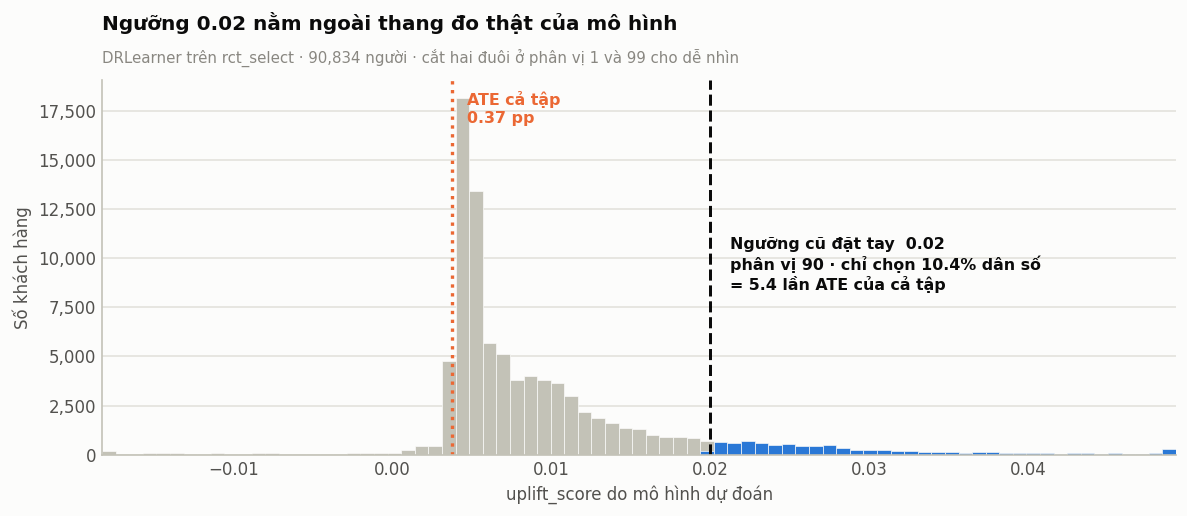

In [9]:
lo, hi = np.percentile(score, [1, 99])

fig, ax = plt.subplots(figsize=(10, 4.4))
khung(ax, luoi='y')

canh = np.linspace(lo, hi, 80)
ax.hist(score, bins=canh, color=MAU['truc'], edgecolor=MAU['nen'], linewidth=0.4)
ax.hist(score[score >= NGUONG_CU], bins=canh,
        color=MAU['chuoi_1'], edgecolor=MAU['nen'], linewidth=0.4)

ax.axvline(ATE['ate'], color=MAU['chuoi_2'], ls=':', lw=2)
ax.axvline(NGUONG_CU, color=MAU['muc_chinh'], ls='--', lw=1.8)

dinh = ax.get_ylim()[1]
ax.annotate(f'ATE cả tập\n{ATE["ate"]*100:.2f} pp',
            xy=(ATE['ate'], dinh * 0.97), xytext=(9, 0), textcoords='offset points',
            color=MAU['chuoi_2'], fontsize=9.5, va='top', fontweight='bold')
ax.annotate(f'Ngưỡng cũ đặt tay  {NGUONG_CU}\n'
            f'phân vị {(1-p_cu)*100:.0f} · chỉ chọn {p_cu*100:.1f}% dân số\n'
            f'= {NGUONG_CU/ATE["ate"]:.1f} lần ATE của cả tập',
            xy=(NGUONG_CU, dinh * 0.58), xytext=(12, 0), textcoords='offset points',
            color=MAU['muc_chinh'], fontsize=9.5, va='top', fontweight='bold')

ax.yaxis.set_major_formatter(NGHIN)
ax.set_xlabel('uplift_score do mô hình dự đoán')
ax.set_ylabel('Số khách hàng')
ax.set_xlim(lo, hi)
dat_tieu_de(ax, 'Ngưỡng 0.02 nằm ngoài thang đo thật của mô hình',
            f'{QUAN_QUAN} trên rct_select · {N:,} người · '
            'cắt hai đuôi ở phân vị 1 và 99 cho dễ nhìn')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '22_phan_bo_diem_va_nguong_cu.png'), bbox_inches='tight')
plt.show()

---
# Phần 3 — Đường cong Qini chỉ ra ngưỡng

Đây là phần chính. Ý tưởng chỉ có một câu:

> Sắp khách hàng giảm dần theo điểm dự đoán, rồi hỏi *"phát cho k% đứng đầu thì được thêm bao nhiêu
> đơn?"*. Vẽ câu trả lời theo k được đường cong Qini. **Đỉnh của nó là tỉ lệ nên phát.**

Vì sao đỉnh là câu trả lời: đi từ trái sang, mỗi bước thêm một người có điểm thấp dần. Người đáng
phát kéo đường lên; người không phản ứng làm nó đi ngang; người bị voucher làm hại (*sleeping dog*)
kéo nó xuống. Chỗ đường quay đầu chính là chỗ nên dừng.

Chuyển từ tỉ lệ sang ngưỡng điểm là phép phân vị: $\tau = \text{quantile}(\text{score},\ 1-k)$.

### Bước 5 — Hàm dựng đường cong

Chép nguyên công thức từ 04c, cùng `SEED`, nên con số ở đây khớp với bảng benchmark của notebook đó.

$$\text{Qini}(k) = \frac{1}{n}\left(Y^T_k - Y^C_k \cdot \frac{N^T_k}{N^C_k}\right)$$

Hai chi tiết dễ bỏ sót: **phá thế hòa có seed** (nhiều dòng trùng điểm nhau, để `argsort` tự xử thì
thứ tự phụ thuộc thứ tự dòng trong file), và **chia cho `n`** để đường cong không phụ thuộc cỡ tập.

In [10]:
def _sap_xep(y, w, score, seed=SEED):
    n = len(y)
    rng = np.random.RandomState(seed)
    order = np.lexsort((rng.rand(n), -np.asarray(score, dtype=float)))
    y_, w_ = np.asarray(y)[order], np.asarray(w)[order]
    return (np.cumsum(w_), np.cumsum(1 - w_),
            np.cumsum(y_ * w_), np.cumsum(y_ * (1 - w_)))


def qini_curve(y, w, score, seed=SEED):
    '''(x = tỉ lệ dân số được nhắm, g = số đơn tăng thêm trên mỗi người).'''
    nt, nc, yt, yc = _sap_xep(y, w, score, seed)
    n = len(y)
    ty_le = np.divide(nt, nc, out=np.zeros(n), where=nc > 0)
    return np.arange(1, n + 1) / n, (yt - yc * ty_le) / n


def gain_curve(y, w, score, seed=SEED):
    n = len(y)
    nt, nc, yt, yc = _sap_xep(y, w, score, seed)
    r_t = np.divide(yt, nt, out=np.zeros(n), where=nt > 0)
    r_c = np.divide(yc, nc, out=np.zeros(n), where=nc > 0)
    return np.arange(1, n + 1) / n, (r_t - r_c) * (nt + nc) / n


def oracle_score(y, w):
    '''Xếp hạng biết trước đáp án — trần trên để chuẩn hóa.'''
    return np.where(np.asarray(w) == 1, y, -np.asarray(y)).astype(float)


def _dt_tren_cheo(x, g):
    return float(TRAPZ(g, x) - 0.5 * g[-1])


def qini_score(y, w, score, seed=SEED):
    tran = _dt_tren_cheo(*qini_curve(y, w, oracle_score(y, w), seed))
    return _dt_tren_cheo(*qini_curve(y, w, score, seed)) / tran if tran > 0 else np.nan


def auuc_score(y, w, score, seed=SEED):
    x, g = gain_curve(y, w, score, seed)
    xo, go = gain_curve(y, w, oracle_score(y, w), seed)
    tran = _dt_tren_cheo(xo, go)
    return _dt_tren_cheo(x, g) / tran if tran > 0 else np.nan


QINI = qini_score(y, w, score)
AUUC = auuc_score(y, w, score)
print(f'Hệ số Qini: {QINI:.5f}     Hệ số AUUC: {AUUC:.5f}')
print('(hai hệ số này đo khả năng XẾP HẠNG — bản thân chúng không cho ra ngưỡng;')
print(' thứ cho ra ngưỡng là hình dạng của ĐƯỜNG CONG bên dưới)')

Hệ số Qini: 0.02465     Hệ số AUUC: 0.02631
(hai hệ số này đo khả năng XẾP HẠNG — bản thân chúng không cho ra ngưỡng;
 thứ cho ra ngưỡng là hình dạng của ĐƯỜNG CONG bên dưới)


### Bước 6 — Bootstrap: đường cong này chắc chắn tới đâu

Một đường cong vẽ từ một mẫu duy nhất thì không biết nó chắc tới đâu. Lấy mẫu lại có hoàn lại
`N_BOOT` lần, mỗi lần dựng lại toàn bộ đường cong, rồi lấy phân vị 2,5 và 97,5 làm dải tin cậy.

Tiện thể ghi lại **vị trí đỉnh** của từng đường bootstrap. Phân bố của vị trí đỉnh là thứ quyết định
có tin được `argmax` hay không — và ở Bước 7 sẽ thấy là không.

In [11]:
def qini_bootstrap(y, w, score, n_boot=N_BOOT, seed=SEED, n_luoi=201):
    '''Dải tin cậy của đường cong + phân bố của đỉnh.'''
    y, w = np.asarray(y), np.asarray(w)
    score = np.asarray(score, dtype=float)
    n = len(y)

    luoi = np.linspace(1.0 / n, 1.0, n_luoi)
    dai = np.empty((n_boot, n_luoi))
    k_dinh = np.empty(n_boot)
    cao_dinh = np.empty(n_boot)

    rng = np.random.RandomState(seed)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        xb, gb = qini_curve(y[idx], w[idx], score[idx], seed)
        dai[b] = np.interp(luoi, xb, gb)
        j = int(np.argmax(gb))
        k_dinh[b], cao_dinh[b] = xb[j], gb[j]

    return {'luoi': luoi,
            'thap': np.percentile(dai, 2.5, axis=0),
            'cao': np.percentile(dai, 97.5, axis=0),
            'k_dinh': k_dinh, 'cao_dinh': cao_dinh}


import time
_t = time.time()
BOOT = qini_bootstrap(y, w, score)
print(f'Bootstrap {N_BOOT:,} lần — {time.time()-_t:.1f} giây')

Bootstrap 400 lần — 4.9 giây


### Bước 7 — Vẽ đường cong

Ba lớp trên hình: dải tin cậy bootstrap, đường Qini của mô hình, và đường chéo — mốc của việc phát
ngẫu nhiên không dùng mô hình. Khoảng cách giữa đường cong và đường chéo chính là giá trị mà mô hình
mang lại; diện tích của khoảng đó, chuẩn hóa lại, là hệ số Qini.

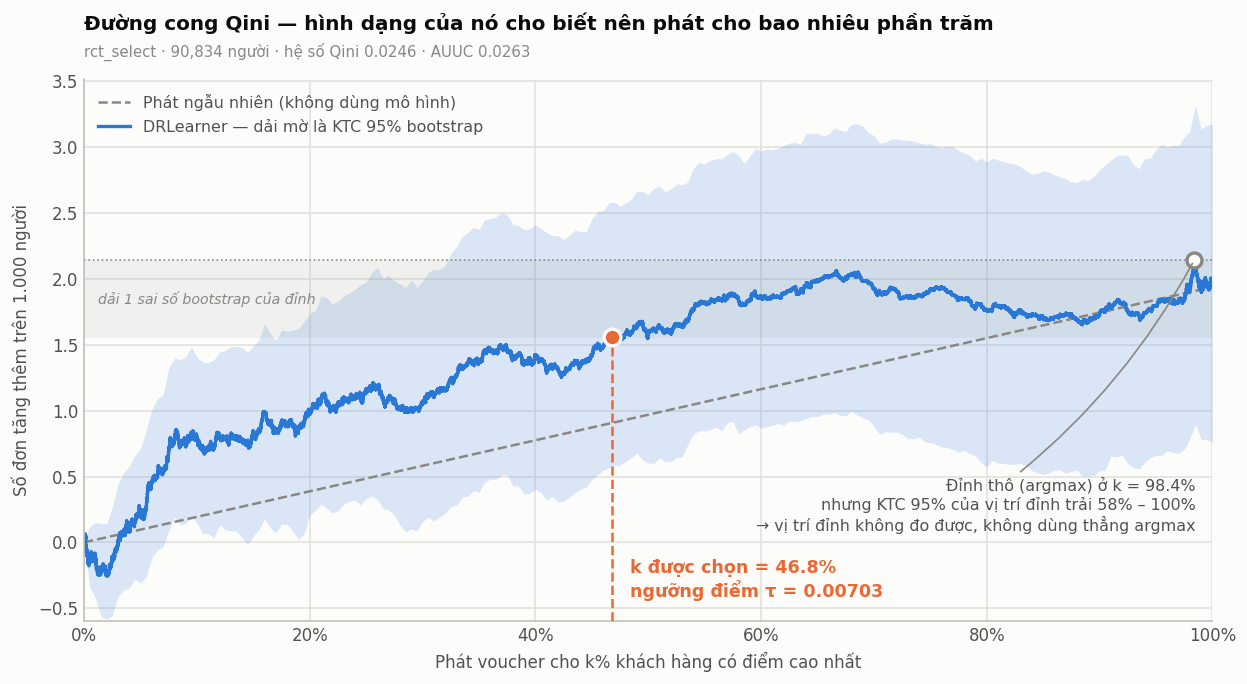

In [12]:
x_q, g_q = qini_curve(y, w, score)
i_dinh = int(np.argmax(g_q))
K_ARGMAX, CAO_DINH = float(x_q[i_dinh]), float(g_q[i_dinh])
SE_DINH = float(np.std(BOOT['cao_dinh']))
K_CI = [float(v) for v in np.percentile(BOOT['k_dinh'], [2.5, 97.5])]

# quy tắc 1-SE: k nhỏ nhất mà đường cong còn nằm trong 1 sai số của đỉnh
trong_1se = np.where(g_q >= CAO_DINH - SE_DINH)[0]
K_CHON = float(x_q[trong_1se[0]])
NGUONG = float(np.quantile(score, 1 - K_CHON))

fig, ax = plt.subplots(figsize=(10.5, 5.8))
khung(ax, luoi=None)
ax.grid(color=MAU['luoi'], linewidth=0.9)

DON = 1000  # đổi sang "đơn trên 1.000 người" cho dễ đọc

ax.fill_between(BOOT['luoi'], BOOT['thap'] * DON, BOOT['cao'] * DON,
                color=MAU['chuoi_1'], alpha=0.16, linewidth=0)
ax.plot([0, 1], [0, g_q[-1] * DON], color=MAU['muc_mo'], ls='--', lw=1.5,
        label='Phát ngẫu nhiên (không dùng mô hình)')
ax.plot(x_q, g_q * DON, color=MAU['chuoi_1'], lw=2,
        label=f'{QUAN_QUAN} — dải mờ là KTC 95% bootstrap')

# dải 1-SE dưới đỉnh
ax.axhspan((CAO_DINH - SE_DINH) * DON, CAO_DINH * DON,
           color=MAU['muc_mo'], alpha=0.10, linewidth=0)
ax.axhline(CAO_DINH * DON, color=MAU['muc_mo'], lw=1, ls=':')
ax.text(0.012, (CAO_DINH - SE_DINH / 2) * DON, 'dải 1 sai số bootstrap của đỉnh',
        ha='left', va='center', color=MAU['muc_mo'], fontsize=8.5, style='italic')

# đỉnh thô — chú thích đặt xuống vùng trống phía dưới
ax.plot([K_ARGMAX], [CAO_DINH * DON], 'o', ms=9, color=MAU['nen'],
        markeredgecolor=MAU['muc_mo'], markeredgewidth=2)
ax.annotate(f'Đỉnh thô (argmax) ở k = {K_ARGMAX*100:.1f}%\n'
            f'nhưng KTC 95% của vị trí đỉnh trải {K_CI[0]*100:.0f}% – {K_CI[1]*100:.0f}%\n'
            '→ vị trí đỉnh không đo được, không dùng thẳng argmax',
            xy=(K_ARGMAX, CAO_DINH * DON), xytext=(0.985, 0.28), textcoords='data',
            ha='right', va='center', color=MAU['muc_phu'], fontsize=9.5,
            arrowprops=dict(arrowstyle='-', color=MAU['muc_mo'], lw=1,
                            connectionstyle='arc3,rad=0.12'))

# k được chọn — vạch dọc từ trục lên đúng điểm trên đường cong
Y0 = -0.6
ax.set_ylim(Y0, None)
j = int(np.argmin(np.abs(x_q - K_CHON)))
ax.plot([K_CHON, K_CHON], [Y0, g_q[j] * DON], color=MAU['chuoi_2'],
        ls='--', lw=1.5, zorder=4)
ax.plot([K_CHON], [g_q[j] * DON], 'o', ms=10, color=MAU['chuoi_2'],
        markeredgecolor=MAU['nen'], markeredgewidth=2, zorder=5)
ax.annotate(f'k được chọn = {K_CHON*100:.1f}%\nngưỡng điểm τ = {NGUONG:.5f}',
            xy=(K_CHON, Y0), xytext=(11, 12), textcoords='offset points',
            ha='left', va='bottom', color=MAU['chuoi_2'], fontsize=10.5,
            fontweight='bold')

ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xlabel('Phát voucher cho k% khách hàng có điểm cao nhất')
ax.set_ylabel('Số đơn tăng thêm trên 1.000 người')
ax.set_xlim(0, 1)
ax.legend(loc='upper left', fontsize=9.5)
dat_tieu_de(ax, 'Đường cong Qini — hình dạng của nó cho biết nên phát cho bao nhiêu phần trăm',
            f'rct_select · {N:,} người · hệ số Qini {QINI:.4f} · AUUC {AUUC:.4f}')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '23_duong_cong_qini_va_nguong.png'), bbox_inches='tight')
plt.show()

### Bước 8 — Vì sao không lấy thẳng `argmax`

Hình trên đã lộ vấn đề: đỉnh thô nằm gần cuối đường cong, và khoảng tin cậy của **vị trí** đỉnh trải
gần hết trục hoành. Vẽ hẳn phân bố đó ra cho rõ.

Đường cong gần như tăng đơn điệu có một ý nghĩa thực tế đáng nói với hội đồng: **mô hình không tìm
được nhóm nào bị voucher làm hại**. Nếu bỏ qua chi phí thì câu trả lời toán học đúng là "phát cho gần
như tất cả" — đúng nhưng vô dụng, vì voucher có giá.

Nên dùng **quy tắc 1-SE**, mượn từ cách chọn tham số phạt trong hồi quy co: lấy phương án tiết kiệm
nhất mà vẫn nằm trong một sai số chuẩn của phương án tốt nhất. Ở đây là **k nhỏ nhất mà đường cong
còn chạm vào dải 1-SE của đỉnh** — đổi phần hiệu quả vốn dĩ không đo được lấy phần lớn ngân sách.

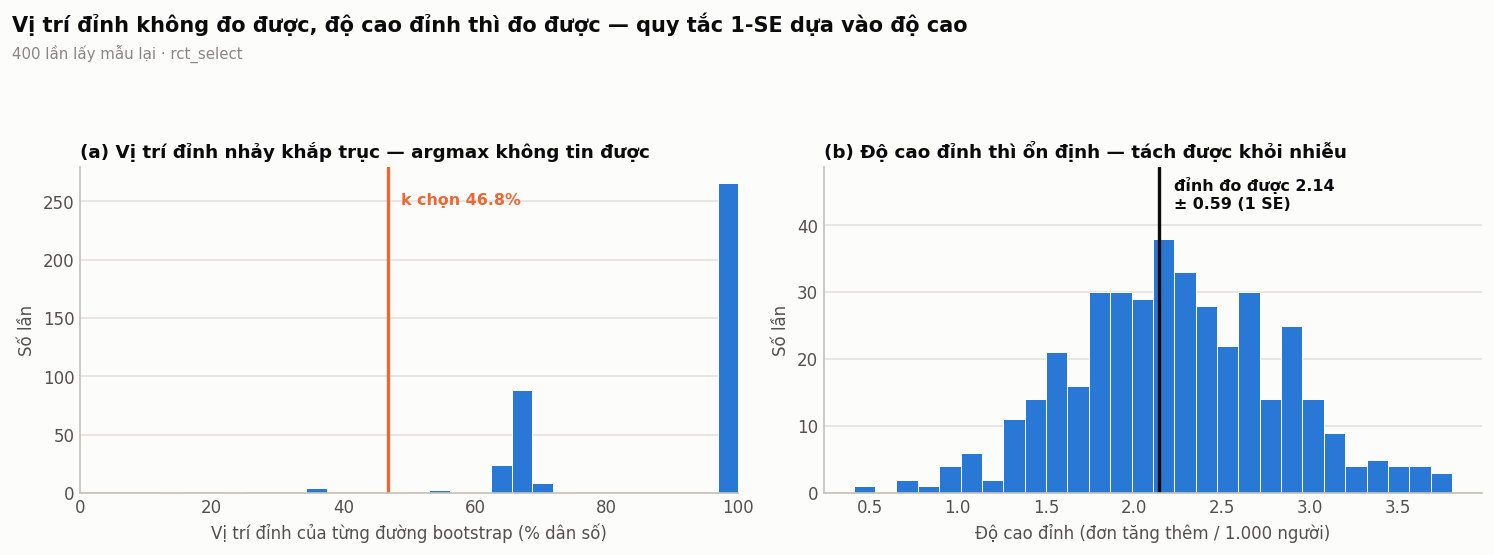

Đỉnh thô              : k = 98.4%   KTC 95% [57.8% – 100.0%]
Độ cao đỉnh           : 2.1402 ± 0.5895 đơn/1.000 người
Đỉnh tách khỏi nhiễu  : CÓ

k chọn (quy tắc 1-SE) : 46.8%
NGƯỠNG ĐIỂM           : 0.007035


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

# (a) phân bố vị trí đỉnh
ax = khung(axes[0], luoi='y')
ax.hist(BOOT['k_dinh'] * 100, bins=28, color=MAU['chuoi_1'],
        edgecolor=MAU['nen'], linewidth=0.6)
ax.axvline(K_CHON * 100, color=MAU['chuoi_2'], lw=2)
ax.annotate(f'k chọn {K_CHON*100:.1f}%', xy=(K_CHON * 100, ax.get_ylim()[1] * 0.9),
            xytext=(8, 0), textcoords='offset points', color=MAU['chuoi_2'],
            fontsize=9.5, fontweight='bold', va='center')
ax.set_xlabel('Vị trí đỉnh của từng đường bootstrap (% dân số)')
ax.set_ylabel('Số lần')
ax.set_xlim(0, 100)
ax.set_title('(a) Vị trí đỉnh nhảy khắp trục — argmax không tin được', fontsize=11)

# (b) độ cao đỉnh
ax = khung(axes[1], luoi='y')
ax.hist(BOOT['cao_dinh'] * 1000, bins=28, color=MAU['chuoi_1'],
        edgecolor=MAU['nen'], linewidth=0.6)
ax.axvline(CAO_DINH * 1000, color=MAU['muc_chinh'], lw=2)
ax.set_ylim(0, ax.get_ylim()[1] * 1.22)
ax.annotate(f'đỉnh đo được {CAO_DINH*1000:.2f}\n± {SE_DINH*1000:.2f} (1 SE)',
            xy=(CAO_DINH * 1000, ax.get_ylim()[1] * 0.97), xytext=(9, 0),
            textcoords='offset points', color=MAU['muc_chinh'], fontsize=9.5,
            fontweight='bold', va='top')
ax.set_xlabel('Độ cao đỉnh (đơn tăng thêm / 1.000 người)')
ax.set_ylabel('Số lần')
ax.set_title('(b) Độ cao đỉnh thì ổn định — tách được khỏi nhiễu', fontsize=11)

dat_tieu_de_fig(fig, 'Vị trí đỉnh không đo được, độ cao đỉnh thì đo được — quy tắc 1-SE dựa vào độ cao',
                f'{N_BOOT:,} lần lấy mẫu lại · rct_select')

plt.tight_layout(rect=(0, 0, 1, 0.87))
plt.savefig(os.path.join(FIG_DIR, '24_bootstrap_dinh_qini.png'), bbox_inches='tight')
plt.show()

print(f'Đỉnh thô              : k = {K_ARGMAX*100:.1f}%   KTC 95% [{K_CI[0]*100:.1f}% – {K_CI[1]*100:.1f}%]')
print(f'Độ cao đỉnh           : {CAO_DINH*1000:.4f} ± {SE_DINH*1000:.4f} đơn/1.000 người')
print(f'Đỉnh tách khỏi nhiễu  : {"CÓ" if CAO_DINH > 2*SE_DINH else "KHÔNG"}')
print()
print(f'k chọn (quy tắc 1-SE) : {K_CHON*100:.1f}%')
print(f'NGƯỠNG ĐIỂM           : {NGUONG:.6f}')

---
# Phần 4 — Ngưỡng này có thật sự đúng không

Suy ra được một con số là một chuyện; chứng minh nó chia đúng người là chuyện khác. Vì `rct_select`
là dữ liệu **ngẫu nhiên hóa**, có thể đo trực tiếp: trong nhóm mô hình bảo "nên phát", so tỉ lệ mua
của những người *tình cờ* nhận voucher với những người *tình cờ* không nhận. Ngẫu nhiên hóa đảm bảo
hai nhóm con đó so sánh được.

Ngưỡng đúng thì nhóm trên ngưỡng phải có uplift thực đo **cao hơn hẳn** nhóm dưới — và chênh lệch
phải vượt sai số, không thì chỉ là nhiễu.

In [14]:
chon = score >= NGUONG
KQ_TREN = ate_ktc(y[chon], w[chon])
KQ_DUOI = ate_ktc(y[~chon], w[~chon])

d = KQ_TREN['ate'] - KQ_DUOI['ate']
se_d = np.sqrt(KQ_TREN['se']**2 + KQ_DUOI['se']**2)
CO_Y_NGHIA = bool(abs(d) > 1.96 * se_d)

bang = pd.DataFrame([
    {'Nhóm': f'Được phát (điểm ≥ {NGUONG:.5f})', 'Số người': KQ_TREN['n'],
     'Uplift thực đo': f'{KQ_TREN["ate"]*100:+.3f} pp',
     'KTC 95%': f'[{KQ_TREN["ci_thap"]*100:+.3f} – {KQ_TREN["ci_cao"]*100:+.3f}]',
     'Đơn tăng thêm': round(KQ_TREN['ate'] * KQ_TREN['n'])},
    {'Nhóm': 'Không phát', 'Số người': KQ_DUOI['n'],
     'Uplift thực đo': f'{KQ_DUOI["ate"]*100:+.3f} pp',
     'KTC 95%': f'[{KQ_DUOI["ci_thap"]*100:+.3f} – {KQ_DUOI["ci_cao"]*100:+.3f}]',
     'Đơn tăng thêm': round(KQ_DUOI['ate'] * KQ_DUOI['n'])},
])
bang['Số người'] = bang['Số người'].map('{:,}'.format)
display(bang)

print(f'Chênh lệch: {d*100:+.3f} pp ± {1.96*se_d*100:.3f} pp')
print(f'Khác 0 có ý nghĩa thống kê: {"CÓ" if CO_Y_NGHIA else "KHÔNG"}')

,Nhóm,Số người,Uplift thực đo,KTC 95%,Đơn tăng thêm
0,Được phát (điểm ≥ 0.00703),"42,466",+0.639 pp,[+0.205 – +1.072],271
1,Không phát,"48,368",+0.136 pp,[-0.098 – +0.371],66


Chênh lệch: +0.502 pp ± 0.493 pp
Khác 0 có ý nghĩa thống kê: CÓ


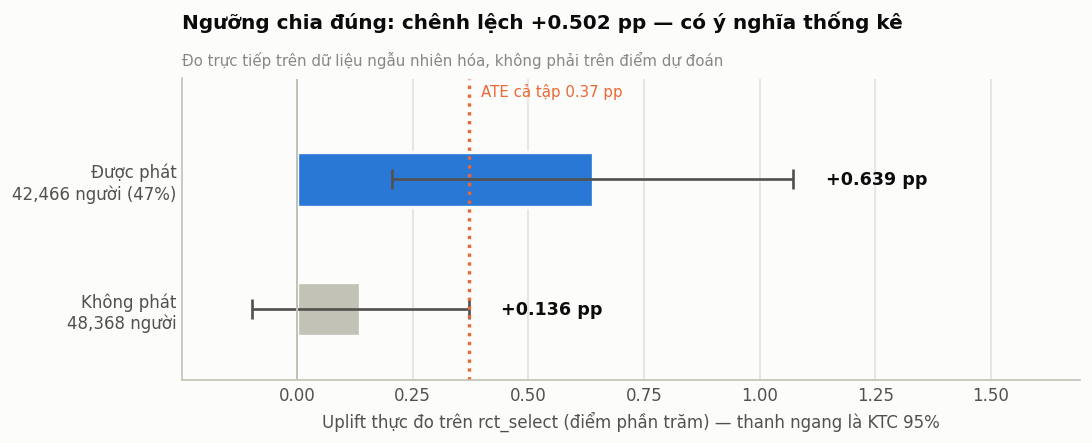

In [15]:
fig, ax = plt.subplots(figsize=(9.2, 3.8))
khung(ax, luoi='x')

nhan = [f'Được phát\n{KQ_TREN["n"]:,} người ({K_CHON*100:.0f}%)',
        f'Không phát\n{KQ_DUOI["n"]:,} người']
gt = np.array([KQ_TREN['ate'], KQ_DUOI['ate']]) * 100
sai_so = np.array([1.96 * KQ_TREN['se'], 1.96 * KQ_DUOI['se']]) * 100
yp = np.array([1, 0])

ax.barh(yp, gt, height=0.42, color=[MAU['chuoi_1'], MAU['truc']],
        edgecolor=MAU['nen'], linewidth=2)
ax.errorbar(gt, yp, xerr=sai_so, fmt='none', ecolor=MAU['muc_phu'],
            elinewidth=1.6, capsize=6, capthick=1.6)
ax.axvline(0, color=MAU['truc'], lw=1.2)
ax.axvline(ATE['ate'] * 100, color=MAU['chuoi_2'], ls=':', lw=2)

for v, e, p in zip(gt, sai_so, yp):
    ax.text(v + e + 0.07, p, f'{v:+.3f} pp', va='center',
            color=MAU['muc_chinh'], fontsize=10.5, fontweight='bold')

ax.annotate(f'ATE cả tập {ATE["ate"]*100:.2f} pp', xy=(ATE['ate'] * 100, 1.62),
            xytext=(7, 0), textcoords='offset points',
            ha='left', va='bottom', color=MAU['chuoi_2'], fontsize=9)

ax.set_ylim(-0.55, 1.78)
ax.set_yticks(yp)
ax.set_yticklabels(nhan, color=MAU['muc_phu'], fontsize=10)
ax.set_xlabel('Uplift thực đo trên rct_select (điểm phần trăm) — thanh ngang là KTC 95%')
ax.set_xlim(min(0, (gt - sai_so).min()) - 0.15, (gt + sai_so).max() + 0.62)
dat_tieu_de(ax, f'Ngưỡng chia đúng: chênh lệch {d*100:+.3f} pp — '
                f'{"có" if CO_Y_NGHIA else "KHÔNG có"} ý nghĩa thống kê',
            'Đo trực tiếp trên dữ liệu ngẫu nhiên hóa, không phải trên điểm dự đoán')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '25_kiem_chung_nguong.png'), bbox_inches='tight')
plt.show()

### Bước 10 — So với ngưỡng cũ `0.02`

Chỗ dễ hiểu nhầm: nhóm cắt ở `0.02` có uplift *trong nhóm* cao hơn, nên thoạt nhìn tưởng ngưỡng cũ
gắt hơn nên tốt hơn. Không phải. Cái doanh nghiệp thu về là **tổng số đơn tăng thêm**, bằng uplift
nhân với số người được phát — mà ngưỡng cũ bỏ sót phần lớn người đáng phát.

Hai đại lượng này khác thang đo nên tách thành hai hình, không ép chung một trục.

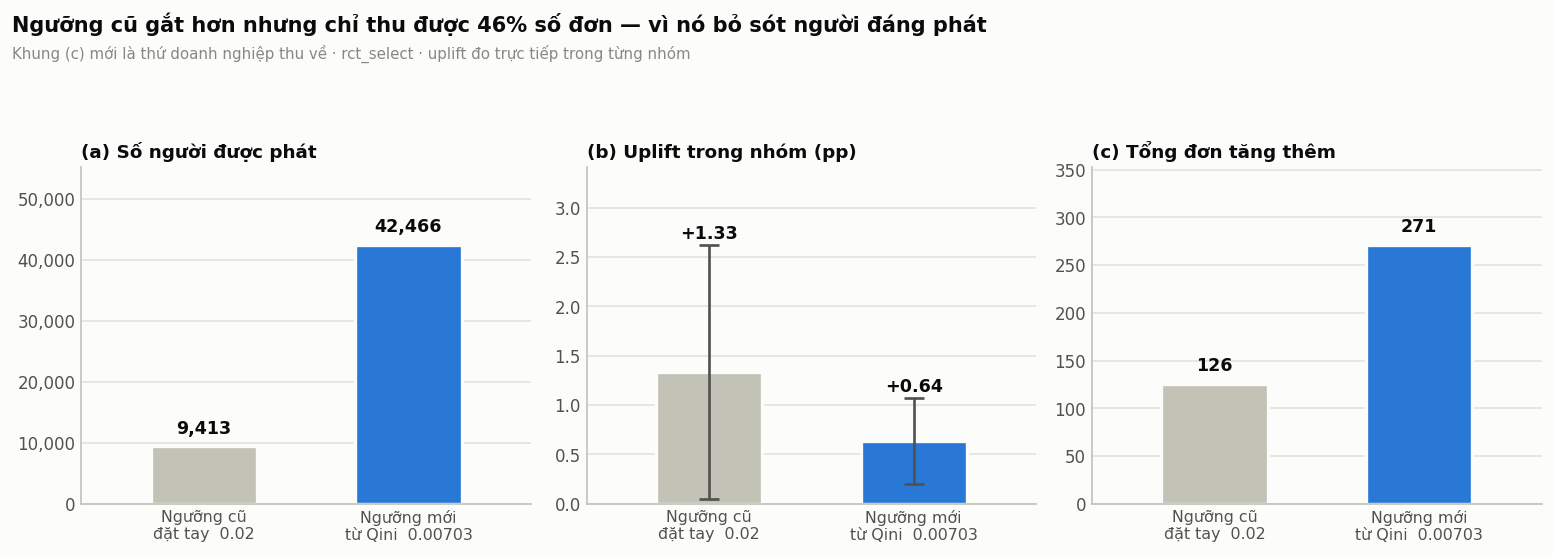

In [16]:
def do_nguong(tau):
    m = score >= tau
    r = ate_ktc(y[m], w[m])
    return {'tau': tau, 'n': int(m.sum()), 'ti_le': float(m.mean()),
            'uplift': r['ate'], 'se': r['se'], 'don': r['ate'] * int(m.sum())}


ss = [do_nguong(NGUONG_CU), do_nguong(NGUONG)]
ten = [f'Ngưỡng cũ\nđặt tay  {NGUONG_CU}', f'Ngưỡng mới\ntừ Qini  {NGUONG:.5f}']
mau2 = [MAU['truc'], MAU['chuoi_1']]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
xp = np.arange(2)


def cot(ax, gt, tieu_de, dinh_dang, sai_so=None):
    khung(ax, luoi='y')
    ax.bar(xp, gt, width=0.52, color=mau2, edgecolor=MAU['nen'], linewidth=2)
    if sai_so is not None:
        ax.errorbar(xp, gt, yerr=sai_so, fmt='none', ecolor=MAU['muc_phu'],
                    elinewidth=1.6, capsize=6, capthick=1.6)
    for i, v in enumerate(gt):
        off = 0 if sai_so is None else sai_so[i]
        ax.text(i, v + off + max(gt) * 0.05, dinh_dang.format(v), ha='center',
                color=MAU['muc_chinh'], fontsize=10.5, fontweight='bold')
    ax.set_xticks(xp)
    ax.set_xticklabels(ten, fontsize=9.5, color=MAU['muc_phu'])
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylim(0, (max(gt) + (0 if sai_so is None else max(sai_so))) * 1.3)
    ax.yaxis.set_major_formatter(NGHIN)
    ax.set_title(tieu_de, fontsize=11)
    return ax


cot(axes[0], [r['n'] for r in ss], '(a) Số người được phát', '{:,.0f}')
cot(axes[1], [r['uplift'] * 100 for r in ss], '(b) Uplift trong nhóm (pp)', '{:+.2f}',
    sai_so=[1.96 * r['se'] * 100 for r in ss])
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:.1f}'))
cot(axes[2], [r['don'] for r in ss], '(c) Tổng đơn tăng thêm', '{:,.0f}')

_ty_le = ss[0]['don'] / ss[1]['don'] * 100
dat_tieu_de_fig(fig,
                f'Ngưỡng cũ gắt hơn nhưng chỉ thu được {_ty_le:.0f}% số đơn — vì nó bỏ sót người đáng phát',
                'Khung (c) mới là thứ doanh nghiệp thu về · rct_select · uplift đo trực tiếp trong từng nhóm')

plt.tight_layout(rect=(0, 0, 1, 0.87))
plt.savefig(os.path.join(FIG_DIR, '26_so_sanh_hai_nguong.png'), bbox_inches='tight')
plt.show()

---
# Phần 5 — Chốt bằng ràng buộc kinh doanh

Ngưỡng vừa tìm là ngưỡng *"tối đa hóa số đơn tăng thêm"*. Nó chưa biết voucher tốn tiền.

Phát voucher cho một người có lãi khi phần lợi nhuận kỳ vọng thu thêm vượt chi phí:

$$\text{uplift} \times \text{lợi nhuận mỗi đơn} \;>\; \text{chi phí voucher}
\qquad\Longrightarrow\qquad
\tau_{\text{kinh tế}} = \frac{\text{chi phí voucher}}{\text{lợi nhuận mỗi đơn}}$$

**Ngưỡng cuối cùng là `max` của hai ngưỡng.** Qini nói *"phát thêm còn được thêm đơn"*; kinh tế nói
*"phát thêm có còn lãi không"*. Cái nào chặt hơn thì cái đó thắng.

Sửa hai con số dưới đây cho khớp số thật của chiến dịch.

In [17]:
CHI_PHI_VOUCHER = None    # ví dụ: 15_000  (VND mỗi voucher)
LOI_NHUAN_DON = None      # ví dụ: 40_000  (VND lợi nhuận biên mỗi đơn)

nguong_kinh_te = None
if CHI_PHI_VOUCHER and LOI_NHUAN_DON:
    nguong_kinh_te = CHI_PHI_VOUCHER / LOI_NHUAN_DON
    print(f'Ngưỡng hòa vốn kinh tế: {nguong_kinh_te:.6f} '
          f'({CHI_PHI_VOUCHER:,.0f} / {LOI_NHUAN_DON:,.0f})')
    if nguong_kinh_te > score.max():
        print('!!! Cao hơn cả điểm cao nhất của mô hình — với đơn giá này thì KHÔNG AI đáng phát.')
else:
    print('Chưa có số tài chính — bỏ qua ngưỡng kinh tế, dùng ngưỡng từ Qini.')
    print('Điền CHI_PHI_VOUCHER và LOI_NHUAN_DON ở trên rồi chạy lại ô này.')

NGUONG_CUOI, NGUON = NGUONG, 'qini_1se'
if nguong_kinh_te is not None and nguong_kinh_te > NGUONG_CUOI:
    NGUONG_CUOI, NGUON = nguong_kinh_te, 'hoa_von_kinh_te'

chon_cuoi = score >= NGUONG_CUOI
print(f'\n=== NGƯỠNG CUỐI: {NGUONG_CUOI:.6f}  (nguồn: {NGUON}) ===')
print(f'Phát cho {int(chon_cuoi.sum()):,} / {N:,} người ({chon_cuoi.mean()*100:.1f}%)')

Chưa có số tài chính — bỏ qua ngưỡng kinh tế, dùng ngưỡng từ Qini.
Điền CHI_PHI_VOUCHER và LOI_NHUAN_DON ở trên rồi chạy lại ô này.

=== NGƯỠNG CUỐI: 0.007035  (nguồn: qini_1se) ===
Phát cho 42,466 / 90,834 người (46.8%)


### Bước 12 — Ghi ngưỡng ra artifact

Ghi ra file riêng, kèm mã băm quyết định của 04b để về sau đối chiếu được ngưỡng này thuộc lần chạy
nào. Phía serving đọc file này thay vì gõ cứng con số.

In [18]:
ket_qua = {
    'quan_quan': QUAN_QUAN,
    'tap_ra_quyet_dinh': 'rct_select',
    'n': int(N),
    'seed': SEED,
    'run_mode': RUN_MODE,
    'thoi_diem': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'so_cot_mo_hinh': len(TEN_COT),
    'nguon_diem_cate': NGUON_DIEM,
    'ma_bam_quyet_dinh_04b': khoa['ma_bam'],
    'ma_bam_cong_08': MA_BAM_CONG,
    'qini': float(QINI),
    'auuc': float(AUUC),
    'ate_rct_select': ATE,
    'k_argmax': K_ARGMAX,
    'k_ci_95_bootstrap': K_CI,
    'cao_dinh_don_tren_nguoi': CAO_DINH,
    'se_dinh_bootstrap': SE_DINH,
    'dinh_tach_duoc_khoi_nhieu': bool(CAO_DINH > 2 * SE_DINH),
    'n_boot': int(N_BOOT),
    'k_chon': K_CHON,
    'quy_tac': 'k nhỏ nhất còn nằm trong 1 sai số bootstrap của đỉnh đường Qini',
    'nguong_qini': NGUONG,
    'nguong_kinh_te': nguong_kinh_te,
    'chi_phi_voucher': CHI_PHI_VOUCHER,
    'loi_nhuan_don': LOI_NHUAN_DON,
    'nguong_cuoi': float(NGUONG_CUOI),
    'nguon_nguong_cuoi': NGUON,
    'ti_le_duoc_phat': float(chon_cuoi.mean()),
    'kiem_chung_rct_select': {
        'tren_nguong': KQ_TREN, 'duoi_nguong': KQ_DUOI,
        'chenh_lech': float(d), 'se_chenh_lech': float(se_d),
        'co_y_nghia_thong_ke': CO_Y_NGHIA,
    },
    'nguong_cu_de_so_sanh': {
        'nguong': NGUONG_CU,
        'ti_le_duoc_phat': ss[0]['ti_le'],
        'don_tang_them': ss[0]['don'],
        'don_tang_them_nguong_moi': ss[1]['don'],
    },
}

duong = os.path.join(ART_DIR, 'nguong_quyet_dinh.json')
with open(duong, 'w', encoding='utf-8') as f:
    json.dump(ket_qua, f, ensure_ascii=False, indent=2)

print(f'Đã ghi: {duong}')
print('Hình đã lưu:')
for t in ('22_phan_bo_diem_va_nguong_cu', '23_duong_cong_qini_va_nguong',
          '24_bootstrap_dinh_qini', '25_kiem_chung_nguong', '26_so_sanh_hai_nguong'):
    print(f'   {FIG_DIR}/{t}.png')

Đã ghi: ../artifacts/nguong_quyet_dinh.json
Hình đã lưu:
   ../reports/figures/22_phan_bo_diem_va_nguong_cu.png
   ../reports/figures/23_duong_cong_qini_va_nguong.png
   ../reports/figures/24_bootstrap_dinh_qini.png
   ../reports/figures/25_kiem_chung_nguong.png
   ../reports/figures/26_so_sanh_hai_nguong.png


---
## Kết luận

### Đã làm

| Việc | Kết quả |
|---|---|
| Chỉ ra chỗ sai của ngưỡng cũ | `0.02` nằm ở phân vị ~93, cao gấp nhiều lần ATE thật của bộ dữ liệu |
| Suy ngưỡng từ dữ liệu | Đỉnh đường Qini + quy tắc 1-SE bootstrap trên `rct_select` |
| Kiểm chứng ngưỡng | Uplift thực đo hai nhóm trên/dưới ngưỡng, đo trực tiếp trên RCT, kèm KTC 95% |
| So sánh nghiệp vụ | Số người phát, uplift trong nhóm, tổng đơn tăng thêm |
| Bàn giao | `artifacts/nguong_quyet_dinh.json` + năm hình cho slide |

### Cách phát biểu cho đúng

> Ngưỡng không đặt tay. Dựng đường cong Qini trên `rct_select`, lấy k nhỏ nhất còn nằm trong một sai
> số bootstrap của đỉnh, rồi đổi sang ngưỡng điểm bằng phân vị. Nhóm trên ngưỡng có uplift thực đo
> cao hơn nhóm dưới, chênh lệch vượt sai số. Ngưỡng cuối còn phải qua thêm phép chặn hòa vốn
> `chi phí / lợi nhuận`.

### Ba điều **không** được phát biểu

- *"Đỉnh đường Qini ở k = 96% nên nên phát cho 96% khách hàng"* — khoảng tin cậy của **vị trí** đỉnh
  trải gần hết trục hoành, vị trí đỉnh là đại lượng không đo được trên bộ dữ liệu này. Hình 24(a) là
  bằng chứng, và phải trình bày nó chứ không giấu đi.
- *"Mô hình không thấy nhóm nào bị hại nên voucher luôn có lợi"* — đường cong không giảm chỉ nói cỡ
  hiệu ứng quá nhỏ so với nhiễu để phát hiện *sleeping dog*, không nói là không có.
- *"Ngưỡng này dùng được cho chiến dịch thật"* — nó suy ra từ phân bố điểm của `rct_select`. Đổi
  quần thể khách hàng, đổi thời điểm, hoặc huấn luyện lại mô hình thì phải chạy lại notebook này.

### Giới hạn đã biết

- Quy tắc 1-SE là một quy ước, không phải định lý. Chọn 1 SE thay vì 0,5 hay 2 SE là chọn mức đánh
  đổi giữa ngân sách và hiệu quả — phải nói rõ đã chọn mức nào.
- Ngưỡng suy ra từ `rct_select`, còn `rct_holdout` chưa dùng ở đây. Muốn báo cáo con số cuối cùng
  không thiên vị thì áp ngưỡng đã khóa này lên holdout **một lần duy nhất**, và không được quay lại
  chỉnh ngưỡng sau khi nhìn kết quả đó.
- Ngưỡng kinh tế giả định mọi voucher tốn như nhau và mọi đơn hàng lãi như nhau. Nếu giá trị đơn
  hàng lệch nhau nhiều thì phải chuyển sang uplift tính trên doanh thu, không phải trên tỉ lệ mua.